# Real-Time Driver Drowsiness Detection Using CNN for Road Safety

## Exploratory Data Analysis (EDA)
  
**Project Type:** Image / Vision  
**Task:** Exploratory Data Analysis and Dataset Preparation

# 1. Dataset Card

## Project Title
**Real-Time Driver Drowsiness Detection Using CNN for Road Safety**

## Dataset Description

The dataset used for this project contains images of human eyes categorized into two classes: **Closed Eyes** and **Open Eyes**. The dataset is intended for binary image classification and will be used to develop a Convolutional Neural Network (CNN) for detecting signs of driver drowsiness.

The main objective is to classify whether a driver's eyes are open or closed. A sequence of closed-eye predictions can be used as an important visual indicator of possible driver drowsiness. The project focuses on computer vision and deep learning for a real-world road-safety application.

## Dataset Classes

| Class | Description |
|---|---|
| Closed_Eyes | Images showing closed eyes |
| Open_Eyes | Images showing open eyes |

## Dataset Size

The dataset contains **4,000 images** in total:

- **Closed_Eyes:** 2,000 images
- **Open_Eyes:** 2,000 images
- **Total:** 4,000 images

The two classes are therefore balanced in terms of the number of images.

## Data Type

The dataset consists of **image data**. The supplied images are grayscale eye images and contain visual information that can be processed using convolutional neural networks.

## Machine Learning Task

**Task:** Binary Image Classification

**Input:** Eye image

**Output:**
- `Closed_Eyes`
- `Open_Eyes`

## Intended Application

The dataset will be used to investigate a CNN-based approach for **real-time driver drowsiness detection**. The larger project goal is to develop a computer-vision system that can identify whether a driver's eyes are closed or open and potentially use this information as part of a road-safety warning system.

## Expected Model

A **Convolutional Neural Network (CNN)** will be used because CNNs are well suited for learning spatial patterns and visual features from image data.

## Important Dataset Consideration

The image filenames contain subject identifiers. Therefore, images from the same subject may be visually similar. During the later model-development stage, the possibility of **subject-level data leakage** must be considered when creating training, validation, and testing sets.

## Dataset Source

**Source:** https://www.kaggle.com/datasets/prasadvpatil/mrl-dataset?utm_

## License

**License:** The person who associated a work with this deed has dedicated the work to the public domain by waiving all of his or her rights to the work worldwide under copyright law, including all related and neighboring rights, to the extent allowed by law.
You can copy, modify, distribute and perform the work, even for commercial purposes, all without asking permission.

https://creativecommons.org/publicdomain/zero/1.0/

## Limitations

The supplied dataset provides images of open and closed eyes, but eye-state classification alone does not fully determine whether a driver is drowsy. A real-world drowsiness detection system may also need temporal information, such as how long the eyes remain closed, blink frequency, head position, or other behavioral indicators.

Therefore, this project should be considered an experimental CNN-based eye-state classification system rather than a complete clinical or safety-certified driver monitoring system.

# 2. Setup/ Import Libraries

In [ ]:
import os
import zipfile
import random
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from IPython.display import display

# Allow PIL to handle image files safely
ImageFile.LOAD_TRUNCATED_IMAGES = False

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")
print(f"Random seed set to: {RANDOM_SEED}")

Libraries imported successfully.
Random seed set to: 42


# 3. Load and Extract Dataset

In [6]:
# Load the dataset

from google.colab import files

print("Please upload your dataset ZIP file.")
uploaded = files.upload()

Please upload your dataset ZIP file.


Saving archive.zip to archive (1).zip


In [8]:
# Extract the uploaded Zip File

zip_name = next(iter(uploaded.keys()))
extract_path = Path("/content/drowsiness_dataset")

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted successfully to: {extract_path}")

Dataset extracted successfully to: /content/drowsiness_dataset


In [13]:
# Inspect the extracted dataset structure

print("Top-level contents:")

for item in sorted(extract_path.iterdir()):
    if item.is_dir():
        print(f" {item.name}/")
    else:
        print(f" {item.name}")

Top-level contents:
 train/


In [12]:
# Inspect the contents of the train folder

train_path = extract_path / "train"

print("Contents of train folder:")

for item in sorted(train_path.iterdir()):
    if item.is_dir():
        print(f" {item.name}/")
    else:
        print(f" {item.name}")

Contents of train folder:
 Closed_Eyes/
 Open_Eyes/


# 4. Create the Dataset Frame

In [14]:
# Define the two class folders
class_names = ["Closed_Eyes", "Open_Eyes"]

# Store image information
image_records = []

for class_name in class_names:
    class_path = train_path / class_name

    for image_path in class_path.iterdir():
        if image_path.is_file():
            image_records.append({
                "filepath": str(image_path),
                "label": class_name,
                "filename": image_path.name
            })

# Create DataFrame
df = pd.DataFrame(image_records)

print("Dataset DataFrame created successfully.")
print(f"Total images: {len(df)}")

# Display the first five records
display(df.head())

Dataset DataFrame created successfully.
Total images: 4000


,filepath,label,filename
0,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,s0013_02046_0_1_0_0_0_01.png
1,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,s0001_01546_0_1_0_0_0_01.png
2,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,s0015_00095_0_0_0_0_1_01.png
3,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,s0016_01300_1_0_0_1_1_01.png
4,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,s0013_01958_0_1_0_0_0_01.png


In [17]:
# Check dataset shape

print("Dataset Shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nNumber of images by class:")
print(df["label"].value_counts())

Dataset Shape:
(4000, 3)

Number of rows: 4000
Number of columns: 3

Number of images by class:
label
Closed_Eyes    2000
Open_Eyes      2000
Name: count, dtype: int64


# 5. Data Types

Before performing image-based exploratory data analysis, the dataset structure is examined to determine the total number of samples and the type of information stored for each image. This helps verify that the dataset has been loaded correctly and provides a clear understanding of the metadata that will be used during the analysis.


In [18]:
# Data Types

print("Data Types:")
print(df.dtypes)

Data Types:
filepath    object
label       object
filename    object
dtype: object


In [19]:
# Dataset Information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  4000 non-null   object
 1   label     4000 non-null   object
 2   filename  4000 non-null   object
dtypes: object(3)
memory usage: 93.9+ KB


In [20]:
# Missing Value Check

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values were found in the dataset metadata.")
else:
    print("\nMissing values were found and should be investigated.")

Missing values in each column:
filepath    0
label       0
filename    0
dtype: int64

No missing values were found in the dataset metadata.


# 6. Five Random Image Samples

To understand the visual characteristics of the dataset, five images are randomly selected and displayed along with their corresponding class labels. This provides an initial visual inspection of the dataset and helps identify differences between the Closed_Eyes and Open_Eyes categories.

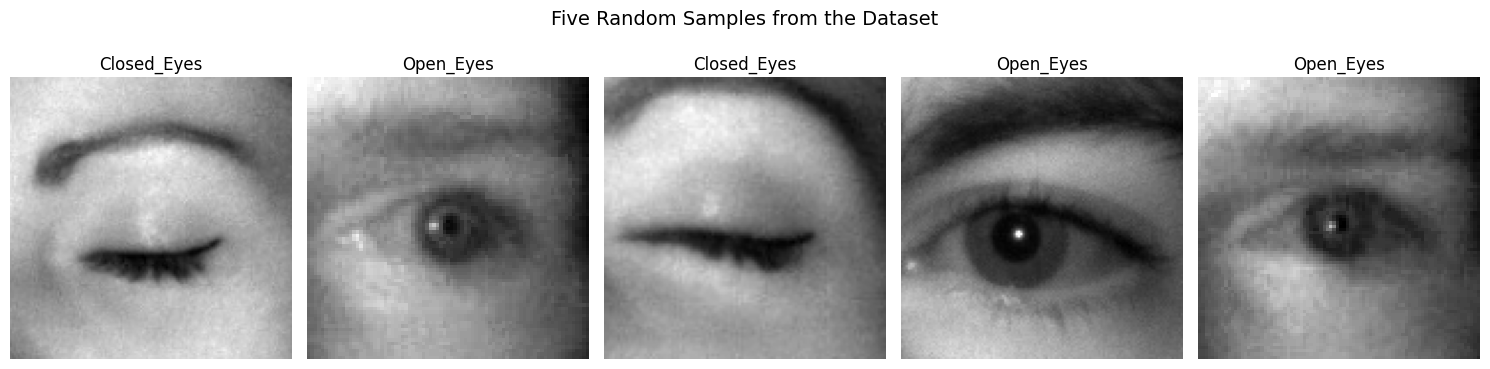

In [21]:
# Select five random images
sample_df = df.sample(n=5, random_state=RANDOM_SEED)

# Create the figure
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image = Image.open(row["filepath"]).convert("L")

    ax.imshow(image, cmap="gray")
    ax.set_title(row["label"])
    ax.axis("off")

plt.suptitle("Five Random Samples from the Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Inspect Image Properties of the Five Samples

print("Image properties of the five random samples:\n")

for _, row in sample_df.iterrows():
    with Image.open(row["filepath"]) as image:
        print(
            f"Filename: {row['filename']} | "
            f"Class: {row['label']} | "
            f"Size: {image.size} | "
            f"Mode: {image.mode}"
        )

Image properties of the five random samples:

Filename: s0016_01000_1_0_0_0_1_01.png | Class: Closed_Eyes | Size: (143, 143) | Mode: L
Filename: s0019_06094_0_0_1_0_0_01.png | Class: Open_Eyes | Size: (81, 81) | Mode: L
Filename: s0016_00262_1_0_0_0_1_01.png | Class: Closed_Eyes | Size: (105, 105) | Mode: L
Filename: s0014_07090_0_0_1_2_1_02.png | Class: Open_Eyes | Size: (123, 123) | Mode: L
Filename: s0019_06035_0_0_1_0_0_01.png | Class: Open_Eyes | Size: (86, 86) | Mode: L


### Initial Visual Observation

The randomly selected samples show that the dataset contains grayscale images representing two eye states: Closed_Eyes and Open_Eyes. The visual difference between the two classes is primarily related to the appearance and openness of the eyes. The samples also show that image dimensions may vary, which indicates that image resizing will be necessary before the images are provided to a CNN with a fixed input size.

# 7. Data Quality Analysis

Before performing further analysis, the dataset is checked for missing, empty, corrupted, and duplicate image files. These checks are important because poor-quality or duplicated samples can affect the reliability of the CNN during training and evaluation.

In [23]:
# Check for Missing, Empty, and Corrupt Images

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

image_files = [
    path for path in train_path.rglob("*")
    if path.is_file() and path.suffix.lower() in valid_extensions
]

zero_byte_files = []
corrupt_files = []

for image_path in image_files:
    # Check for zero-byte files
    if image_path.stat().st_size == 0:
        zero_byte_files.append(str(image_path))
        continue

    # Check whether the image can be opened and verified
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        corrupt_files.append(str(image_path))

print(f"Total image files found: {len(image_files)}")
print(f"Zero-byte files: {len(zero_byte_files)}")
print(f"Corrupt/unreadable images: {len(corrupt_files)}")

Total image files found: 4000
Zero-byte files: 0
Corrupt/unreadable images: 0


In [24]:
# Check for Exact Duplicate Images

hashes = {}
duplicate_files = []

for image_path in image_files:
    try:
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hashes:
            duplicate_files.append(
                (str(image_path), hashes[file_hash])
            )
        else:
            hashes[file_hash] = str(image_path)

    except Exception:
        pass

print(f"Unique file hashes: {len(hashes)}")
print(f"Duplicate files beyond the first copy: {len(duplicate_files)}")

Unique file hashes: 4000
Duplicate files beyond the first copy: 0


In [25]:
# Data Quality Summary

print("========== DATA QUALITY SUMMARY ==========")
print(f"Total image files:              {len(image_files)}")
print(f"Zero-byte files:                {len(zero_byte_files)}")
print(f"Corrupt/unreadable images:      {len(corrupt_files)}")
print(f"Duplicate files:                {len(duplicate_files)}")
print("==========================================")

if len(zero_byte_files) == 0 and len(corrupt_files) == 0:
    print("✓ No empty or corrupt images were detected.")

if len(duplicate_files) == 0:
    print("✓ No exact duplicate image files were detected.")

========== DATA QUALITY SUMMARY ==========
Total image files:              4000
Zero-byte files:                0
Corrupt/unreadable images:      0
Duplicate files:                0
✓ No empty or corrupt images were detected.
✓ No exact duplicate image files were detected.


# 8. Class Distribution Analysis

The class distribution is examined to determine whether the dataset is balanced between the two target categories. Class imbalance can affect the training of a classification model because a model may become biased toward a class with substantially more training examples.

In [26]:
# Class Distribution

class_counts = df["label"].value_counts()

print("Class Distribution:")
display(class_counts.to_frame(name="Number of Images"))

Class Distribution:


,Number of Images
label,
Closed_Eyes,2000
Open_Eyes,2000


In [27]:
# Class Percentages and Balance Ratio

class_percentages = (class_counts / len(df) * 100).round(2)

print("Class Percentages:")
for class_name, percentage in class_percentages.items():
    print(f"{class_name}: {percentage}%")

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print(f"\nMajority-to-minority ratio: {imbalance_ratio:.2f}:1")

Class Percentages:
Closed_Eyes: 50.0%
Open_Eyes: 50.0%

Majority-to-minority ratio: 1.00:1


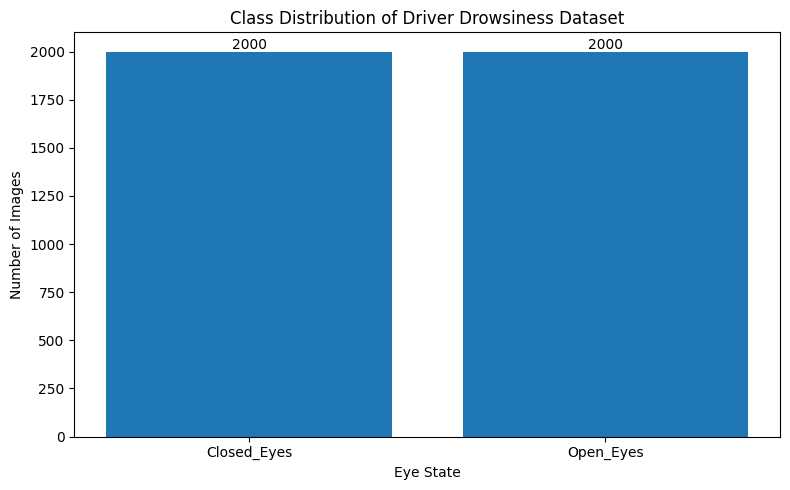

In [28]:
# Visualize Class Distribution

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Class Distribution of Driver Drowsiness Dataset")
plt.xlabel("Eye State")
plt.ylabel("Number of Images")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Class Distribution Findings

The dataset contains an equal number of images in the Closed_Eyes and Open_Eyes categories. Each class represents 50% of the complete dataset, resulting in a majority-to-minority ratio of 1.00:1. Therefore, the dataset does not show class imbalance based on the number of available images.

This balanced distribution is beneficial for binary CNN classification because the model has an equal number of examples available for learning both eye states. However, class balance alone does not guarantee unbiased model performance, since other factors such as subject distribution, image quality, lighting conditions, and similarities between images may also affect generalization.

# 9. Subject Distribution and Potential Data Leakage

The dataset filenames contain subject identifiers, which can be used to examine how images are distributed among different subjects. This analysis is important because images from the same subject may share visual characteristics. If images from the same subject are randomly divided between the training and testing sets, the model may encounter very similar subject-specific features during training and testing. This can lead to overly optimistic evaluation results.

Therefore, subject-level separation should be considered when designing the training, validation, and testing strategy for the CNN.

In [29]:
# Extract Subject IDs from Filenames

import re

def extract_subject_id(filename):
    """
    Extract the subject identifier from filenames containing
    patterns such as s0001, s0016, etc.
    """
    match = re.search(r"s\d+", filename.lower())
    return match.group(0) if match else "Unknown"

df["subject_id"] = df["filename"].apply(extract_subject_id)

print("Number of unique subjects:")
print(df["subject_id"].nunique())

print("\nFirst 10 subject IDs:")
display(df[["filename", "label", "subject_id"]].head(10))

Number of unique subjects:
16

First 10 subject IDs:


,filename,label,subject_id
0,s0013_02046_0_1_0_0_0_01.png,Closed_Eyes,s0013
1,s0001_01546_0_1_0_0_0_01.png,Closed_Eyes,s0001
2,s0015_00095_0_0_0_0_1_01.png,Closed_Eyes,s0015
3,s0016_01300_1_0_0_1_1_01.png,Closed_Eyes,s0016
4,s0013_01958_0_1_0_0_0_01.png,Closed_Eyes,s0013
5,s0016_01058_1_0_0_0_1_01.png,Closed_Eyes,s0016
6,s0016_00855_1_0_0_1_1_01.png,Closed_Eyes,s0016
7,s0036_00117_1_0_0_0_0_01.png,Closed_Eyes,s0036
8,s0015_00092_0_0_0_0_1_01.png,Closed_Eyes,s0015
9,s0016_00433_1_0_0_0_1_01.png,Closed_Eyes,s0016


In [30]:
# Subject Distribution by Class

subject_class_counts = pd.crosstab(
    df["subject_id"],
    df["label"]
)

print("Subject distribution by class:")
display(subject_class_counts)

Subject distribution by class:


label,Closed_Eyes,Open_Eyes
subject_id,,
s0001,384,333
s0002,34,0
s0006,100,0
s0012,0,472
s0013,117,0
s0014,94,469
s0015,61,0
s0016,902,0
s0017,31,3


In [31]:
# Subjects Represented in Both Classes

both_classes = (
    (subject_class_counts.get("Closed_Eyes", 0) > 0) &
    (subject_class_counts.get("Open_Eyes", 0) > 0)
)

closed_only = (
    (subject_class_counts.get("Closed_Eyes", 0) > 0) &
    (subject_class_counts.get("Open_Eyes", 0) == 0)
)

open_only = (
    (subject_class_counts.get("Closed_Eyes", 0) == 0) &
    (subject_class_counts.get("Open_Eyes", 0) > 0)
)

print("Subject-level summary:")
print(f"Total unique subjects: {df['subject_id'].nunique()}")
print(f"Subjects with both classes: {both_classes.sum()}")
print(f"Subjects with Closed_Eyes only: {closed_only.sum()}")
print(f"Subjects with Open_Eyes only: {open_only.sum()}")

Subject-level summary:
Total unique subjects: 16
Subjects with both classes: 8
Subjects with Closed_Eyes only: 5
Subjects with Open_Eyes only: 3


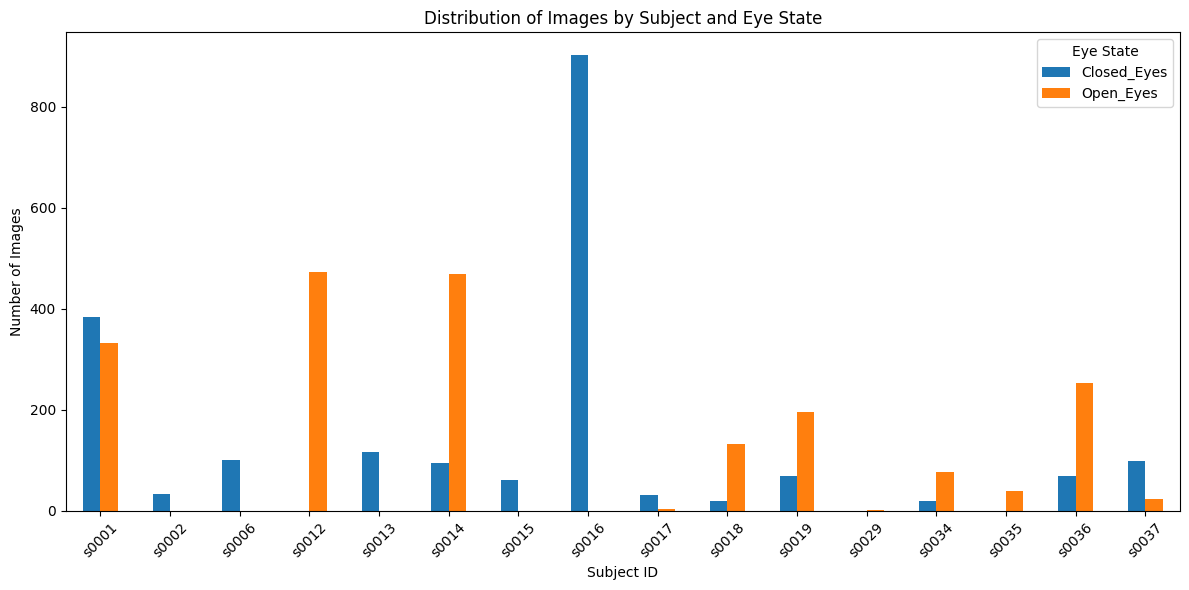

In [32]:
# Visualize Subject Distribution by Class

subject_class_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribution of Images by Subject and Eye State")
plt.xlabel("Subject ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(title="Eye State")
plt.tight_layout()
plt.show()

In [33]:
# Analyze Potential Subject-Level Data Leakage

subjects_both_classes = subject_class_counts[
    (subject_class_counts["Closed_Eyes"] > 0) &
    (subject_class_counts["Open_Eyes"] > 0)
].index

images_from_both_class_subjects = df[
    df["subject_id"].isin(subjects_both_classes)
].shape[0]

print("Potential Data Leakage Analysis")
print("--------------------------------")
print(f"Subjects represented in both classes: {len(subjects_both_classes)}")
print(f"Images from these subjects: {images_from_both_class_subjects}")
print(
    f"Percentage of dataset from these subjects: "
    f"{images_from_both_class_subjects / len(df) * 100:.2f}%"
)

Potential Data Leakage Analysis
--------------------------------
Subjects represented in both classes: 8
Images from these subjects: 2272
Percentage of dataset from these subjects: 56.80%


### Subject-Level Findings

The dataset contains 16 unique subjects, with eight subjects represented in both the Closed_Eyes and Open_Eyes classes. The remaining subjects appear in only one of the two classes. This demonstrates that the overall 50%-50% class balance does not necessarily represent balanced subject-level coverage.

Subject identity is important for this project because images from the same person can share visual characteristics. If images from the same subject are randomly divided across training and testing sets, the CNN may learn subject-specific characteristics and obtain an overly optimistic test performance. Therefore, a subject-aware splitting strategy should be considered when developing the final CNN model so that evaluation better represents performance on unseen subjects.

# 10. Image Dimensions, Channels, and Pixel Statistics

Image dimensions, color mode, and pixel intensity statistics are examined to understand the visual structure of the dataset. These characteristics are important when preparing image data for a Convolutional Neural Network (CNN), because CNN models generally require images to have a consistent input size and channel configuration.

In [34]:
# Analyze Image Dimensions and Channels

image_properties = []

for _, row in df.iterrows():
    try:
        with Image.open(row["filepath"]) as img:
            width, height = img.size

            # Determine number of channels
            if img.mode == "L":
                channels = 1
            elif img.mode == "RGB":
                channels = 3
            elif img.mode == "RGBA":
                channels = 4
            else:
                channels = len(img.getbands())

            image_properties.append({
                "filepath": row["filepath"],
                "label": row["label"],
                "width": width,
                "height": height,
                "mode": img.mode,
                "channels": channels
            })

    except Exception as e:
        print(f"Could not process: {row['filepath']}")

image_properties_df = pd.DataFrame(image_properties)

print("Image properties collected successfully.")
print(f"Images analyzed: {len(image_properties_df)}")

display(image_properties_df.head())

Image properties collected successfully.
Images analyzed: 4000


,filepath,label,width,height,mode,channels
0,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,99,99,L,1
1,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,97,97,L,1
2,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,95,95,L,1
3,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,109,109,L,1
4,/content/drowsiness_dataset/train/Closed_Eyes/...,Closed_Eyes,90,90,L,1


In [35]:
# Unique Image Dimensions

dimension_counts = (
    image_properties_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Unique image dimensions:")
display(dimension_counts)

Unique image dimensions:


,width,height,count
35,95,95,100
25,85,85,95
33,93,93,95
37,97,97,93
26,86,86,89
...,...,...,...
4,64,64,1
0,60,60,1
111,171,171,1
113,178,178,1


In [36]:
# Image Mode and Channel Distribution

print("Image Mode Distribution:")
display(
    image_properties_df["mode"]
    .value_counts()
    .to_frame(name="Number of Images")
)

print("\nChannel Distribution:")
display(
    image_properties_df["channels"]
    .value_counts()
    .sort_index()
    .to_frame(name="Number of Images")
)

Image Mode Distribution:


,Number of Images
mode,
L,4000



Channel Distribution:


,Number of Images
channels,
1,4000


In [45]:
# Calculate Pixel Intensity Statistics

pixel_means = []
pixel_stds = []
pixel_mins = []
pixel_maxs = []

for _, row in df.iterrows():
    try:
        with Image.open(row["filepath"]).convert("L") as img:
            pixels = np.array(img, dtype=np.float32)

            pixel_means.append(pixels.mean())
            pixel_stds.append(pixels.std())
            pixel_mins.append(pixels.min())
            pixel_maxs.append(pixels.max())

    except Exception:
        pass

pixel_stats = pd.DataFrame({
    "mean": pixel_means,
    "std": pixel_stds,
    "min": pixel_mins,
    "max": pixel_maxs
})

print("Pixel Statistics Summary:")
display(pixel_stats.describe())

Pixel Statistics Summary:


,mean,std,min,max
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,93.057236,23.171062,38.500751,176.858246
std,25.918058,10.834386,20.582752,59.275974
min,50.133968,6.932364,0.000000,74.000000
25%,76.376690,14.634459,29.000000,122.000000
50%,85.290848,19.433892,42.000000,178.000000
75%,109.284542,28.615053,53.000000,255.000000
max,154.848831,53.043026,80.000000,255.000000


In [40]:
# Pixel Statistics by Class

pixel_records = []

for _, row in df.iterrows():
    try:
        with Image.open(row["filepath"]).convert("L") as img:
            pixels = np.array(img, dtype=np.float32)

            pixel_records.append({
                "filename": row["filename"],
                "label": row["label"],
                "mean": pixels.mean(),
                "std": pixels.std(),
                "min": pixels.min(),
                "max": pixels.max()
            })

    except Exception:
        pass

pixel_stats_df = pd.DataFrame(pixel_records)

class_pixel_stats = (
    pixel_stats_df
    .groupby("label")[["mean", "std", "min", "max"]]
    .mean()
    .round(2)
)

print("Average Pixel Statistics by Class:")
display(class_pixel_stats)

Average Pixel Statistics by Class:


,mean,std,min,max
label,,,,
Closed_Eyes,102.449997,18.200001,51.32,153.050003
Open_Eyes,83.669998,28.139999,25.68,200.669998


In [46]:
# Improved Pixel Statistics by Class

pixel_records = []

for _, row in df.iterrows():
    try:
        with Image.open(row["filepath"]).convert("L") as img:
            pixels = np.array(img, dtype=np.float32)

            pixel_records.append({
                "filename": row["filename"],
                "label": row["label"],
                "mean": pixels.mean(),
                "std": pixels.std(),
                "min": pixels.min(),
                "max": pixels.max()
            })

    except Exception:
        pass

pixel_stats_df = pd.DataFrame(pixel_records)

class_pixel_stats = (
    pixel_stats_df
    .groupby("label")[["mean", "std", "min", "max"]]
    .mean()
    .round(2)
)

print("Average Pixel Statistics by Class:")
display(class_pixel_stats)

Average Pixel Statistics by Class:


,mean,std,min,max
label,,,,
Closed_Eyes,102.449997,18.200001,51.32,153.050003
Open_Eyes,83.669998,28.139999,25.68,200.669998


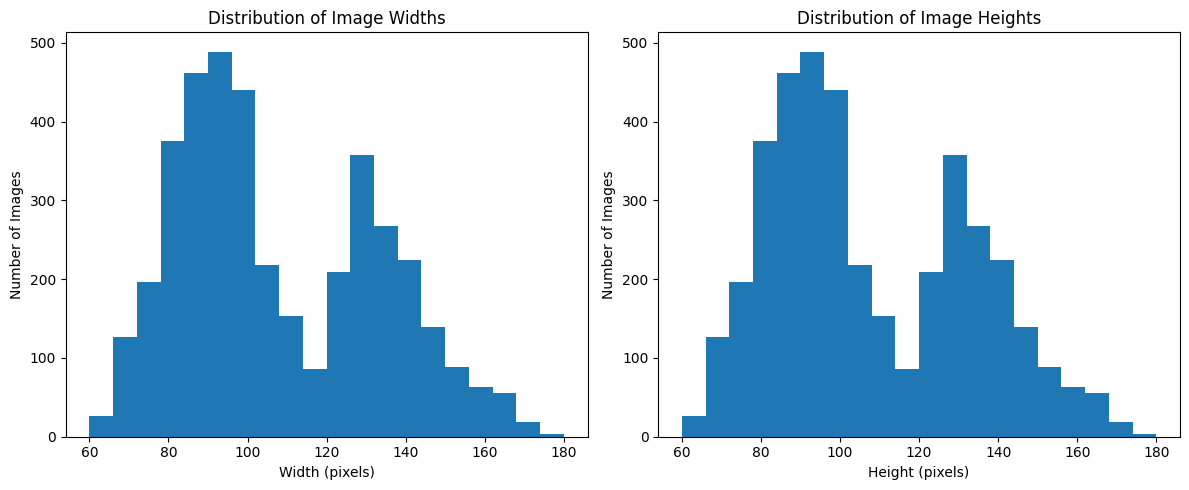

In [42]:
# Image Dimension Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(image_properties_df["width"], bins=20)
axes[0].set_title("Distribution of Image Widths")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Number of Images")

axes[1].hist(image_properties_df["height"], bins=20)
axes[1].set_title("Distribution of Image Heights")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

# 11. Class-wise Image Visualization

Visualizing multiple samples from each class provides a clearer understanding of the visual differences within and between the target categories. In this dataset, the two classes represent Closed_Eyes and Open_Eyes. Examining several samples is useful because individual images may differ in lighting, eye shape, orientation, and other visual characteristics.

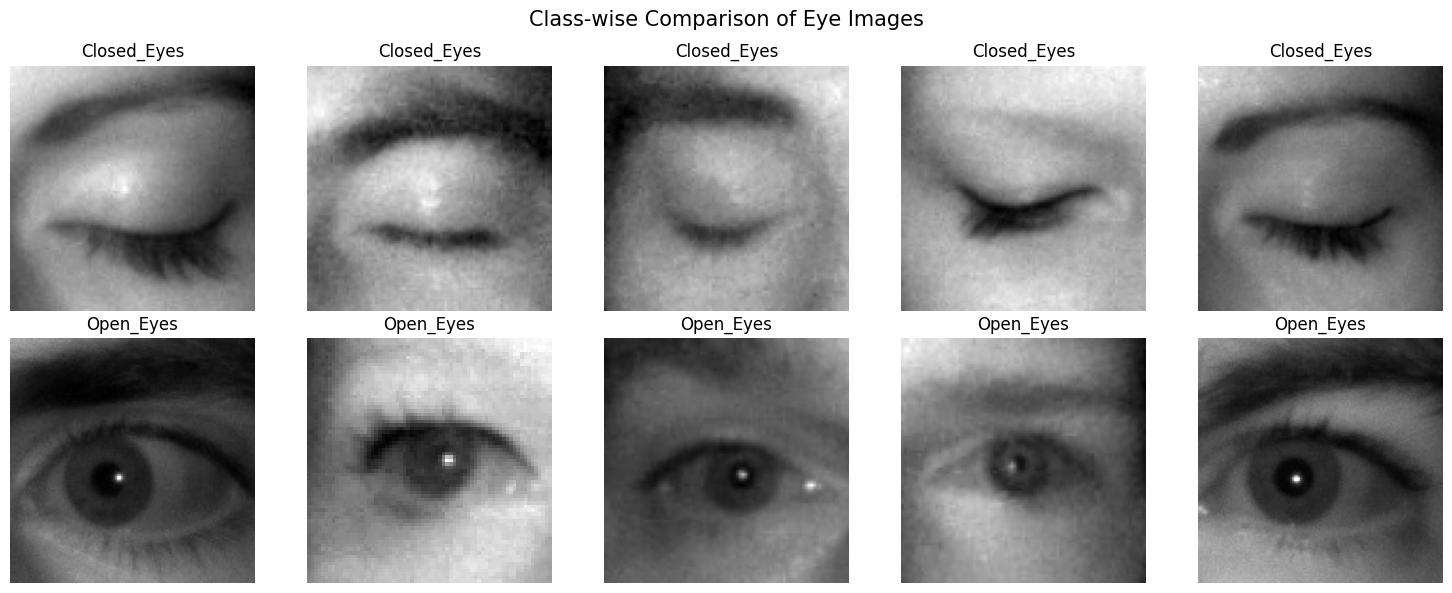

In [47]:
# Class-wise Sample Visualization

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row_index, class_name in enumerate(class_names):

    # Select 5 random images from the current class
    class_samples = df[df["label"] == class_name].sample(
        n=5,
        random_state=RANDOM_SEED
    )

    for col_index, (_, row) in enumerate(class_samples.iterrows()):
        image = Image.open(row["filepath"]).convert("L")

        axes[row_index, col_index].imshow(image, cmap="gray")
        axes[row_index, col_index].set_title(class_name)
        axes[row_index, col_index].axis("off")

plt.suptitle(
    "Class-wise Comparison of Eye Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [48]:
# Visual Variation by Class

visual_summary = (
    pixel_stats_df
    .groupby("label")[["mean", "std"]]
    .agg(["mean", "std"])
    .round(2)
)

print("Visual intensity variation by class:")
display(visual_summary)

Visual intensity variation by class:


mean                   std       
                   mean        std       mean    std
label                                               
Closed_Eyes  102.449997  29.410000  18.200001   5.95
Open_Eyes     83.669998  17.389999  28.139999  12.25

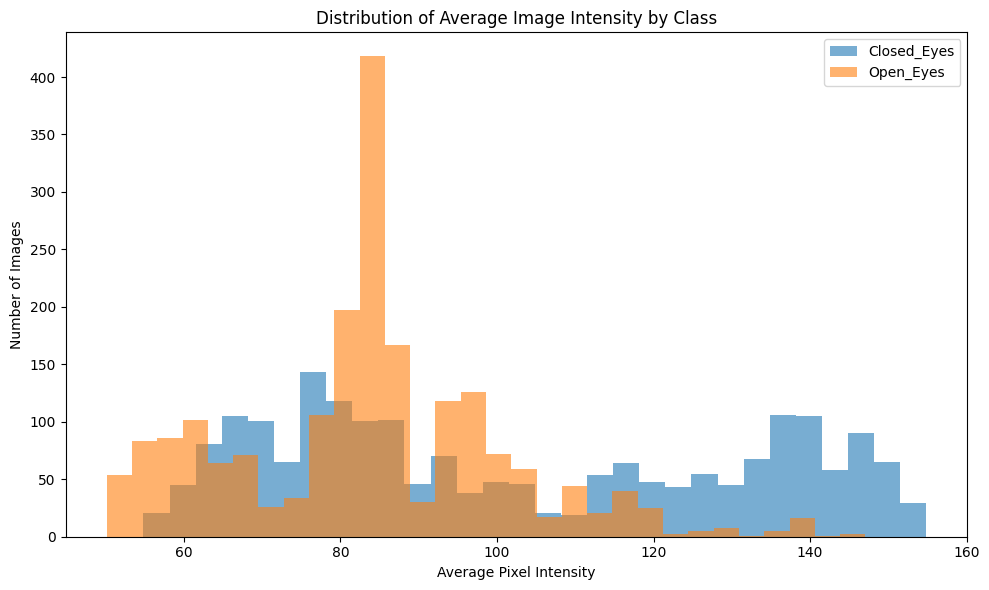

In [49]:
# Compare Pixel Intensity Distributions by Class

plt.figure(figsize=(10, 6))

for class_name in class_names:
    class_data = pixel_stats_df[
        pixel_stats_df["label"] == class_name
    ]["mean"]

    plt.hist(
        class_data,
        bins=30,
        alpha=0.6,
        label=class_name
    )

plt.title("Distribution of Average Image Intensity by Class")
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()
plt.show()

### Class-wise Visual Findings

The class-wise visualization demonstrates noticeable visual differences between the Closed_Eyes and Open_Eyes categories, while also showing variation within each class. The pixel-intensity distribution indicates that Closed_Eyes images generally have higher average pixel intensity, whereas Open_Eyes images are more concentrated at lower intensity values. However, the two distributions show substantial overlap, particularly in the middle intensity range. This indicates that average brightness alone is not sufficient to reliably distinguish between the two eye states. A CNN is therefore appropriate because it can learn spatial features and more complex visual patterns associated with open and closed eyes.

# 12. Mean Image Analysis

Mean images are generated for the Closed_Eyes and Open_Eyes classes to examine their average visual patterns. Since the original images have different dimensions, they are temporarily resized to a common resolution before averaging. This analysis provides a visual comparison of the typical pixel structure of each class and can help identify broad differences between the two eye states.

In [51]:
# Generate Mean Images for Each Class

MEAN_IMAGE_SIZE = (64, 64)

mean_images = {}

for class_name in class_names:
    class_images = []

    class_df = df[df["label"] == class_name]

    for _, row in class_df.iterrows():
        try:
            with Image.open(row["filepath"]).convert("L") as img:
                img = img.resize(MEAN_IMAGE_SIZE)
                class_images.append(np.array(img, dtype=np.float32))
        except Exception:
            pass

    mean_images[class_name] = np.mean(class_images, axis=0)

print("Mean images generated successfully.")
print(f"Mean image resolution: {MEAN_IMAGE_SIZE}")

Mean images generated successfully.
Mean image resolution: (64, 64)


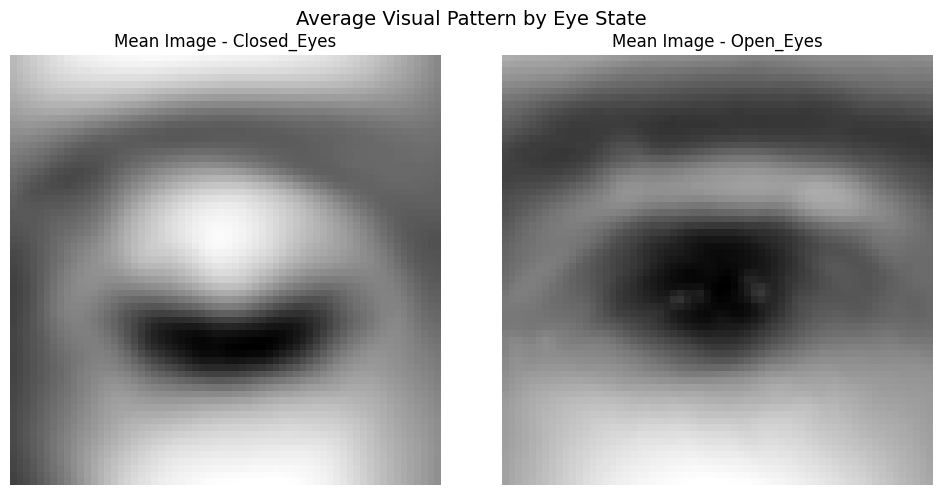

In [52]:
# Visualize Mean Images

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, class_name in zip(axes, class_names):
    ax.imshow(mean_images[class_name], cmap="gray")
    ax.set_title(f"Mean Image - {class_name}")
    ax.axis("off")

plt.suptitle("Average Visual Pattern by Eye State", fontsize=14)
plt.tight_layout()
plt.show()

In [53]:
# Calculate Mean Image Difference

mean_difference = np.abs(
    mean_images["Closed_Eyes"] -
    mean_images["Open_Eyes"]
)

print("Mean absolute pixel difference:")
print(f"{mean_difference.mean():.2f}")

print("\nMaximum pixel difference:")
print(f"{mean_difference.max():.2f}")

Mean absolute pixel difference:
19.79

Maximum pixel difference:
68.86


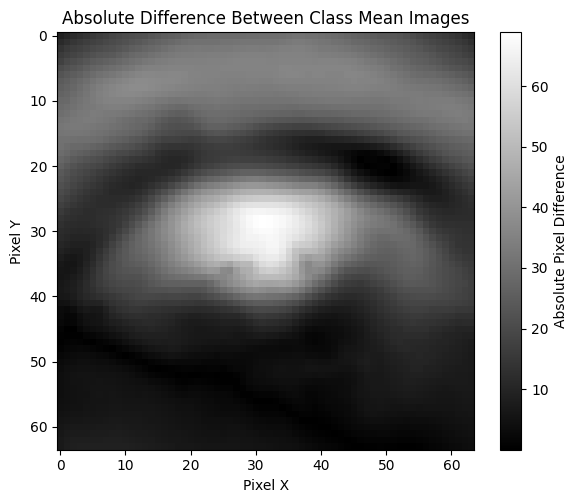

In [54]:
# Visualize Difference Between Mean Images

plt.figure(figsize=(6, 5))

plt.imshow(mean_difference, cmap="gray")
plt.title("Absolute Difference Between Class Mean Images")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.colorbar(label="Absolute Pixel Difference")

plt.tight_layout()
plt.show()

### Mean Image Findings

The mean image analysis provides a visual representation of the typical appearance of each eye-state class. The mean Closed_Eyes image shows a darker horizontal region corresponding to the closed eyelid, while the mean Open_Eyes image shows a more distinct dark central region associated with the visible pupil and iris.

The absolute difference image highlights regions where the average visual patterns of the two classes differ most strongly. The mean absolute pixel difference is 19.79, while the maximum pixel difference is 68.86. These differences indicate that the two classes contain distinguishable spatial patterns that can potentially be learned by a convolutional neural network.

However, the mean images represent averages across many subjects and should not be interpreted as an exact representation of every individual image. The analysis is therefore used as an exploratory visualization rather than as a classification method.

# 13. Image Preprocessing Analysis

Before training the CNN, the images need to be converted into a consistent format. The dataset contains grayscale images with a single channel, but the image dimensions are not uniform. Therefore, the preprocessing pipeline will resize all images to a common resolution and normalize their pixel values. These steps help provide consistent input to the neural network and make model training more stable.

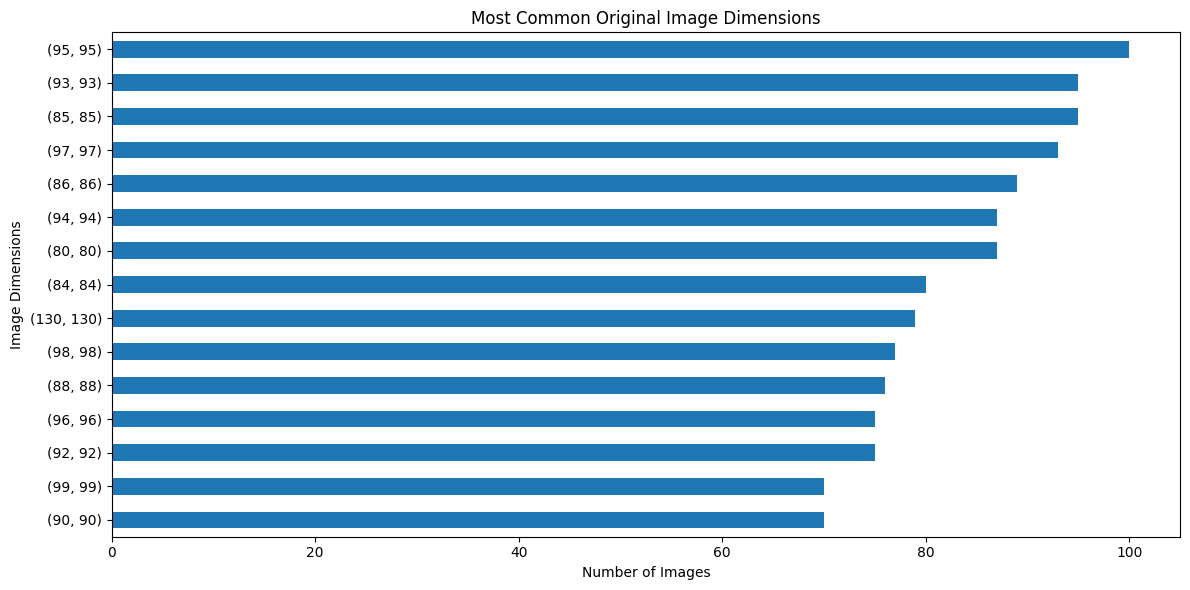

In [55]:
# Distribution of Original Image Dimensions

dimension_counts = (
    image_properties_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

top_dimensions = dimension_counts.head(15)

plt.figure(figsize=(12, 6))

top_dimensions.sort_values().plot(
    kind="barh"
)

plt.title("Most Common Original Image Dimensions")
plt.xlabel("Number of Images")
plt.ylabel("Image Dimensions")

plt.tight_layout()
plt.show()

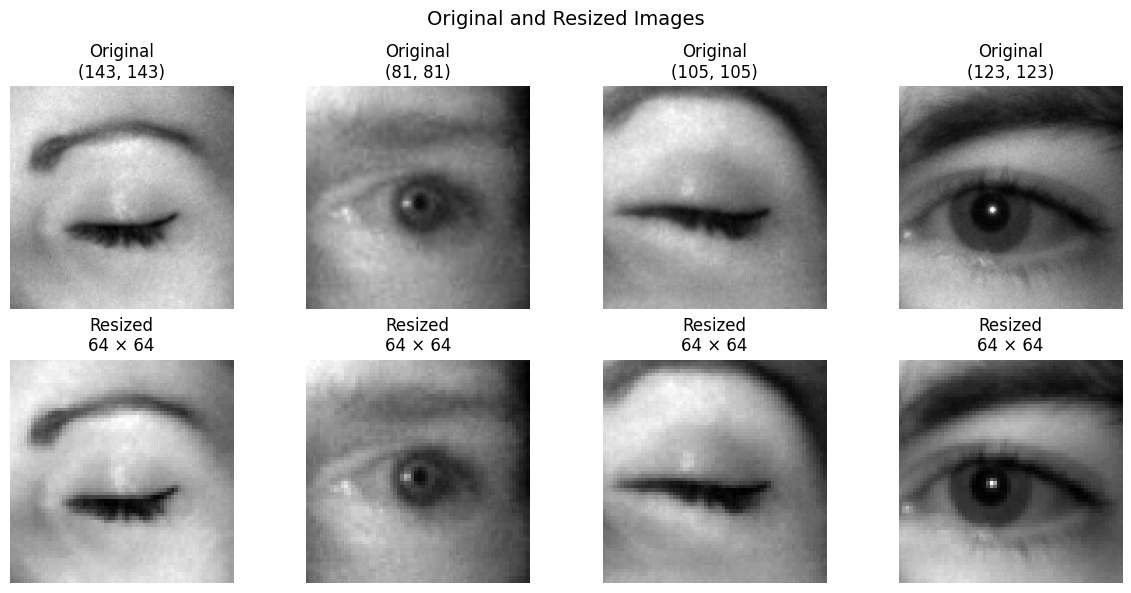

In [56]:
# Original vs. Resized Images

sample_images = df.sample(
    n=4,
    random_state=RANDOM_SEED
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for col, (_, row) in enumerate(sample_images.iterrows()):

    # Original image
    original = Image.open(row["filepath"]).convert("L")

    axes[0, col].imshow(original, cmap="gray")
    axes[0, col].set_title(
        f"Original\n{original.size}"
    )
    axes[0, col].axis("off")

    # Resized image
    resized = original.resize((64, 64))

    axes[1, col].imshow(resized, cmap="gray")
    axes[1, col].set_title("Resized\n64 × 64")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Resized", fontsize=11)

plt.suptitle(
    "Original and Resized Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [57]:
# Pixel Normalization Demonstration

sample_row = df.sample(
    n=1,
    random_state=RANDOM_SEED
).iloc[0]

image = Image.open(sample_row["filepath"]).convert("L")
image = image.resize((64, 64))

pixels_original = np.array(image, dtype=np.float32)

pixels_normalized = pixels_original / 255.0

print("Original pixel range:")
print(f"Minimum: {pixels_original.min():.2f}")
print(f"Maximum: {pixels_original.max():.2f}")

print("\nNormalized pixel range:")
print(f"Minimum: {pixels_normalized.min():.4f}")
print(f"Maximum: {pixels_normalized.max():.4f}")

Original pixel range:
Minimum: 70.00
Maximum: 171.00

Normalized pixel range:
Minimum: 0.2745
Maximum: 0.6706


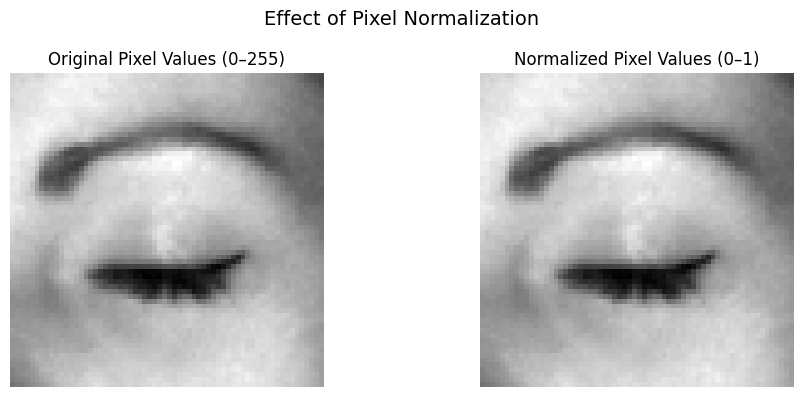

In [64]:
# Original vs. Normalized Image

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(pixels_original, cmap="gray")
axes[0].set_title("Original Pixel Values (0–255)")
axes[0].axis("off")

axes[1].imshow(pixels_normalized, cmap="gray")
axes[1].set_title("Normalized Pixel Values (0–1)")
axes[1].axis("off")

plt.suptitle(
    "Effect of Pixel Normalization",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Preprocessing Findings

The analysis confirms that the dataset contains images with varying original dimensions, as demonstrated by the different image sizes observed in the dataset. Since a CNN requires a consistent input shape, all images will be resized to 64 × 64 pixels before model training. The images are already grayscale and contain a single channel, so RGB conversion is not required.

The original images contain pixel values on a scale of 0 to 255. Pixel normalization will transform these values to a smaller numerical scale by dividing each pixel value by 255. For the randomly selected image analyzed, the pixel range changed from 70–171 to 0.2745–0.6706 after normalization. The visual appearance of the image remained essentially unchanged after normalization.

Therefore, the planned preprocessing pipeline consists of resizing the images to 64 × 64 pixels, retaining the single grayscale channel, and normalizing pixel values to the 0–1 range. This will provide consistent input data for the CNN model.

## 14. Subject-Level Train, Validation, and Test Split

The dataset contains multiple images from the same subjects. Therefore, randomly splitting individual images could result in images from the same subject appearing in both the training and testing sets. This may lead to subject-level data leakage and produce overly optimistic model performance.

To reduce this risk, the dataset will be divided at the subject level. All images belonging to a particular subject will remain in the same partition. The dataset will be divided into training, validation, and testing sets, while maintaining awareness of the class distribution in each partition.

In [59]:
# Subject-Level Dataset Summary

print("Total unique subjects:", df["subject_id"].nunique())

subject_summary = (
    df.groupby("subject_id")["label"]
    .agg(["count", "nunique"])
    .sort_values("count", ascending=False)
)

print("\nImages per subject:")
display(subject_summary)

Total unique subjects: 16

Images per subject:


,count,nunique
subject_id,,
s0016,902,1
s0001,717,2
s0014,563,2
s0012,472,1
s0036,323,2
s0019,265,2
s0018,152,2
s0037,122,2
s0013,117,1


In [60]:
# Subject-Level Train/Validation/Test Split

from sklearn.model_selection import GroupShuffleSplit

# First split: 80% subjects for development, 20% for test
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_val_idx, test_idx = next(
    gss_test.split(
        df,
        y=df["label"],
        groups=df["subject_id"]
    )
)

train_val_df = df.iloc[train_val_idx].copy()
test_df = df.iloc[test_idx].copy()

# Second split: approximately 20% of the development set for validation
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_idx, val_idx = next(
    gss_val.split(
        train_val_df,
        y=train_val_df["label"],
        groups=train_val_df["subject_id"]
    )
)

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print("Dataset split completed.")
print("--------------------------------")
print(f"Training images:   {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Testing images:    {len(test_df)}")

Dataset split completed.
--------------------------------
Training images:   2127
Validation images: 236
Testing images:    1637


In [61]:
# Check Subject Separation

train_subjects = set(train_df["subject_id"])
val_subjects = set(val_df["subject_id"])
test_subjects = set(test_df["subject_id"])

print("Training subjects:", sorted(train_subjects))
print("\nValidation subjects:", sorted(val_subjects))
print("\nTesting subjects:", sorted(test_subjects))

print("\n========== SUBJECT OVERLAP CHECK ==========")

print("Train ∩ Validation:", train_subjects.intersection(val_subjects))
print("Train ∩ Test:", train_subjects.intersection(test_subjects))
print("Validation ∩ Test:", val_subjects.intersection(test_subjects))

Training subjects: ['s0012', 's0013', 's0015', 's0016', 's0017', 's0018', 's0019', 's0029', 's0037']

Validation subjects: ['s0006', 's0034', 's0035']

Testing subjects: ['s0001', 's0002', 's0014', 's0036']

========== SUBJECT OVERLAP CHECK ==========
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [62]:
# Class Distribution Across Splits

split_distribution = pd.DataFrame({
    "Training": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Testing": test_df["label"].value_counts()
}).fillna(0).astype(int)

display(split_distribution)

print("\nClass percentages:")
for split_name, split_data in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Testing", test_df)
]:
    percentages = (
        split_data["label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print(f"\n{split_name}:")
    print(percentages)

,Training,Validation,Testing
label,,,
Closed_Eyes,1299,120,581
Open_Eyes,828,116,1056



Class percentages:

Training:
label
Closed_Eyes    61.07
Open_Eyes      38.93
Name: proportion, dtype: float64

Validation:
label
Closed_Eyes    50.85
Open_Eyes      49.15
Name: proportion, dtype: float64

Testing:
label
Open_Eyes      64.51
Closed_Eyes    35.49
Name: proportion, dtype: float64


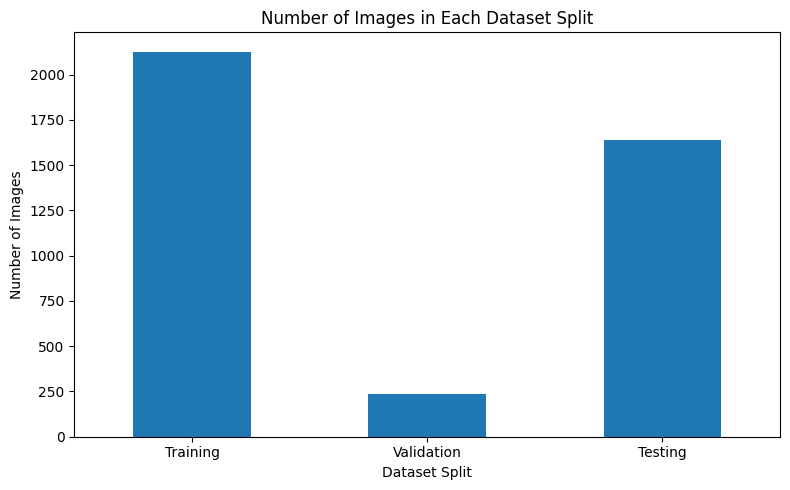

In [63]:
# Dataset Split Visualization

split_sizes = pd.Series({
    "Training": len(train_df),
    "Validation": len(val_df),
    "Testing": len(test_df)
})

plt.figure(figsize=(8, 5))

split_sizes.plot(kind="bar")

plt.title("Number of Images in Each Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation:
The dataset was divided into training, validation, and testing sets using a subject-level split to reduce the possibility of data leakage. A total of 2,127 images were assigned to training, 236 to validation, and 1,637 to testing. The subject-overlap check confirmed that there were no common subjects between any two splits. Although the class distribution differs across the splits, both eye-state classes are represented in each set. The absence of subject overlap provides a more reliable basis for evaluating how well the CNN can generalize to previously unseen subjects.

# 15. Image Preprocessing

In [66]:
import numpy as np
from PIL import Image
from tqdm import tqdm

IMG_SIZE = (64, 64)

# Label mapping
label_map = {
    "Closed_Eyes": 0,
    "Open_Eyes": 1
}

def load_and_preprocess_images(dataframe):
    images = []
    labels = []

    for _, row in tqdm(dataframe.iterrows(),
                       total=len(dataframe),
                       desc="Processing images"):

        try:
            # Open image
            image = Image.open(row["filepath"]).convert("L")

            # Resize to 64x64
            image = image.resize(IMG_SIZE)

            # Convert to NumPy array
            image = np.array(image, dtype=np.float32)

            # Normalize pixel values to 0-1
            image = image / 255.0

            # Add channel dimension for CNN
            image = np.expand_dims(image, axis=-1)

            images.append(image)
            labels.append(label_map[row["label"]])

        except Exception as e:
            print(f"Error processing {row['filepath']}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


# Process each dataset split
X_train, y_train = load_and_preprocess_images(train_df)
X_val, y_val = load_and_preprocess_images(val_df)
X_test, y_test = load_and_preprocess_images(test_df)


# ============================================================
# VERIFY PREPROCESSED DATA
# ============================================================

print("\n========== PREPROCESSING SUMMARY ==========")

print(f"Training data shape:   {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")

print(f"Validation data shape:   {X_val.shape}")
print(f"Validation labels shape: {y_val.shape}")

print(f"Testing data shape:   {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

print("\nPixel value range:")
print(f"Training minimum: {X_train.min():.4f}")
print(f"Training maximum: {X_train.max():.4f}")

print("\nLabel encoding:")
print("Closed_Eyes = 0")
print("Open_Eyes   = 1")

print("\n============================================")

Processing images: 100%|██████████| 1637/1637 [00:01<00:00, 1609.27it/s]


========== PREPROCESSING SUMMARY ==========
Training data shape:   (2127, 64, 64, 1)
Training labels shape: (2127,)
Validation data shape:   (236, 64, 64, 1)
Validation labels shape: (236,)
Testing data shape:   (1637, 64, 64, 1)
Testing labels shape: (1637,)

Pixel value range:
Training minimum: 0.0000
Training maximum: 1.0000

Label encoding:
Closed_Eyes = 0
Open_Eyes   = 1



### Interpretation

All images were successfully preprocessed for CNN training. The images were converted to grayscale and resized to a uniform resolution of 64 × 64 pixels. Pixel values were normalized to a range of 0 to 1 to provide a consistent numerical input for the neural network. The images were also given a single-channel dimension because the original dataset consists of grayscale images. The class labels were encoded as 0 for Closed_Eyes and 1 for Open_Eyes. The final shapes confirm that the training, validation, and testing datasets are correctly prepared for CNN development.

## 16. Data Augmentation

Data augmentation is applied to the training images to improve the CNN's ability to generalize to variations in eye position, orientation, and image scale. The augmentation is limited to realistic transformations so that the original meaning of the eye-state images is preserved.

Only the training dataset is augmented. Validation and testing datasets are kept unchanged to ensure an unbiased evaluation of the trained CNN.

In [67]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)

# Data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        mode="horizontal"
    ),
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),
    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),
], name="data_augmentation")

print("Data augmentation pipeline created successfully.")
print("\nAugmentation operations:")
print("✓ Horizontal flipping")
print("✓ Small random rotation")
print("✓ Small random zoom")
print("\nAugmentation will be applied only to the training data.")

Data augmentation pipeline created successfully.

Augmentation operations:
✓ Horizontal flipping
✓ Small random rotation
✓ Small random zoom

Augmentation will be applied only to the training data.


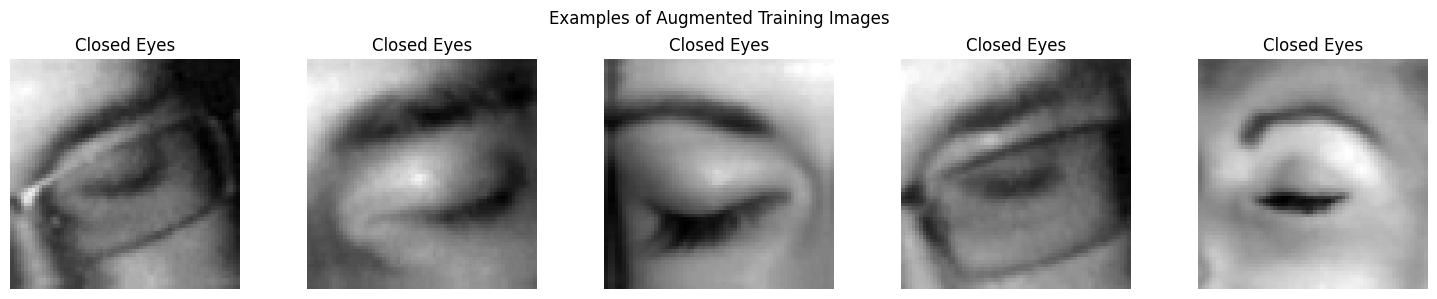

In [68]:
# ============================================================
# VISUALIZE AUGMENTED TRAINING IMAGES
# ============================================================

# Select a few training images
sample_images = X_train[:5]

plt.figure(figsize=(15, 3))

for i in range(5):
    # Add batch dimension
    image = tf.expand_dims(sample_images[i], axis=0)

    # Apply augmentation
    augmented_image = data_augmentation(image, training=True)

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(
        "Closed Eyes" if y_train[i] == 0 else "Open Eyes"
    )

plt.suptitle("Examples of Augmented Training Images")
plt.tight_layout()
plt.show()

# 17. CNN Model Architecture

A Convolutional Neural Network (CNN) is developed to classify eye images into two categories: Closed_Eyes and Open_Eyes. The model uses convolutional layers to learn spatial features from the eye images, followed by pooling and fully connected layers for classification.

The input images have a resolution of 64 × 64 pixels with one grayscale channel. Data augmentation is included in the model so that augmentation is applied during training while validation and testing images remain unchanged.

In [69]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Create CNN model
cnn_model = models.Sequential([

    # Input and data augmentation
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Flatten extracted features
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary classification output
    layers.Dense(1, activation="sigmoid")
])

# Display model architecture
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# ============================================================
# COMPILE CNN MODEL
# ============================================================

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")
print("Optimizer: Adam")
print("Loss function: Binary Crossentropy")
print("Metric: Accuracy")

CNN model compiled successfully.
Optimizer: Adam
Loss function: Binary Crossentropy
Metric: Accuracy


# 18. CNN Model Training

The CNN model is trained using the preprocessed training dataset. Class weights are calculated to account for the difference in class distribution in the training data. The validation dataset is used to monitor model performance during training.

Early stopping is used to stop training when validation performance no longer improves, helping reduce unnecessary training and potential overfitting.

In [72]:


from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(classes[i]): float(class_weights_array[i])
    for i in range(len(classes))
}

print("========== CLASS WEIGHTS ==========")

for class_id, weight in class_weights.items():
    class_name = "Closed_Eyes" if class_id == 0 else "Open_Eyes"
    print(f"{class_name} (class {class_id}): {weight:.4f}")

print("===================================")

========== CLASS WEIGHTS ==========
Closed_Eyes (class 0): 0.8187
Open_Eyes (class 1): 1.2844


In [73]:
# Train CNN Model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save the best model
model_checkpoint = ModelCheckpoint(
    "best_drowsiness_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train the CNN
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

print("\n========== TRAINING COMPLETED ==========")
print(f"Epochs actually completed: {len(history.history['loss'])}")
print("Best CNN model saved as: best_drowsiness_cnn.keras")
print("========================================")

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7433 - loss: 0.5276
Epoch 1: val_loss improved from None to 0.30670, saving model to best_drowsiness_cnn.keras

Epoch 1: finished saving model to best_drowsiness_cnn.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8322 - loss: 0.3583 - val_accuracy: 0.8644 - val_loss: 0.3067
Epoch 2/30
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1041
Epoch 2: val_loss improved from 0.30670 to 0.10740, saving model to best_drowsiness_cnn.keras

Epoch 2: finished saving model to best_drowsiness_cnn.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9694 - loss: 0.0857 - val_accuracy: 0.9703 - val_loss: 0.1074
Epoch 3/30
64/67 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9870 - loss: 0.0452
Epoch 3: val_loss improved from 0.10740 to 0.05507, saving model to best_drowsiness_cnn.keras

Epoch 3: finished saving model to best_drowsiness_cnn.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 

# 19. Training Performance Visualization

The training history is visualized using accuracy and loss curves for both the training and validation datasets. These plots help evaluate the learning behavior of the CNN and identify potential overfitting during training.

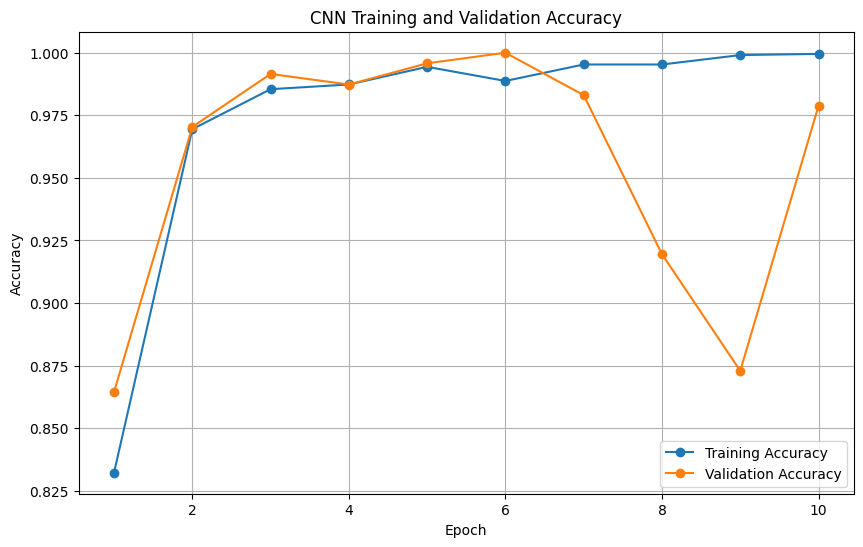

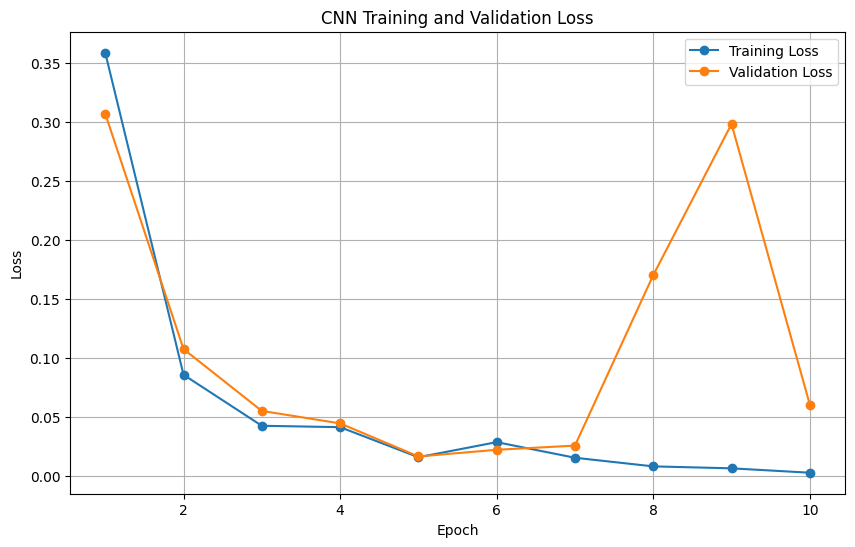

In [74]:
import matplotlib.pyplot as plt

# Extract training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)


# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# CNN Test Evaluation

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best model saved during training
best_model = load_model("best_drowsiness_cnn.keras")

# Evaluate on the unseen test set
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("========== TEST SET EVALUATION ==========")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print("=========================================")

# Generate predictions
y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Classification report
print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Closed_Eyes", "Open_Eyes"],
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\n========== CONFUSION MATRIX ==========")
print(cm)

========== TEST SET EVALUATION ==========
Test Loss:      0.2519
Test Accuracy:  0.9493
Test Accuracy:  94.93%

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

 Closed_Eyes     0.8784    0.9948    0.9330       581
   Open_Eyes     0.9969    0.9242    0.9592      1056

    accuracy                         0.9493      1637
   macro avg     0.9377    0.9595    0.9461      1637
weighted avg     0.9549    0.9493    0.9499      1637


========== CONFUSION MATRIX ==========
[[578   3]
 [ 80 976]]


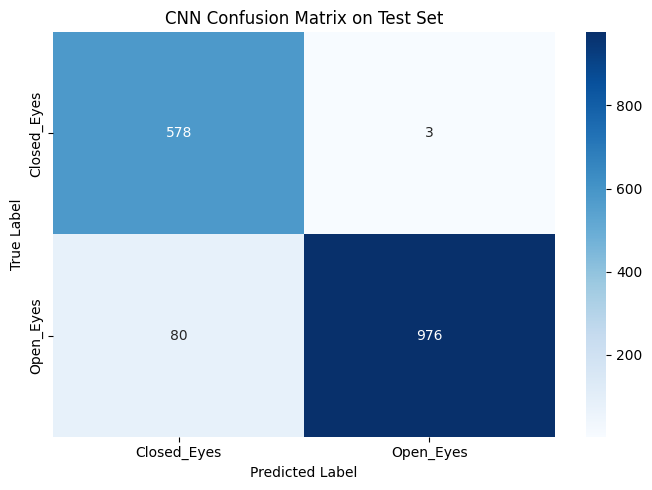

In [76]:
# CONFUSION MATRIX VISUALIZATION

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Closed_Eyes", "Open_Eyes"],
    yticklabels=["Closed_Eyes", "Open_Eyes"]
)

plt.title("CNN Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 20. ROC CURVE AND AUC ANALYSIS

========== ROC-AUC ANALYSIS ==========
ROC-AUC Score: 0.9846
ROC-AUC Score: 98.46%


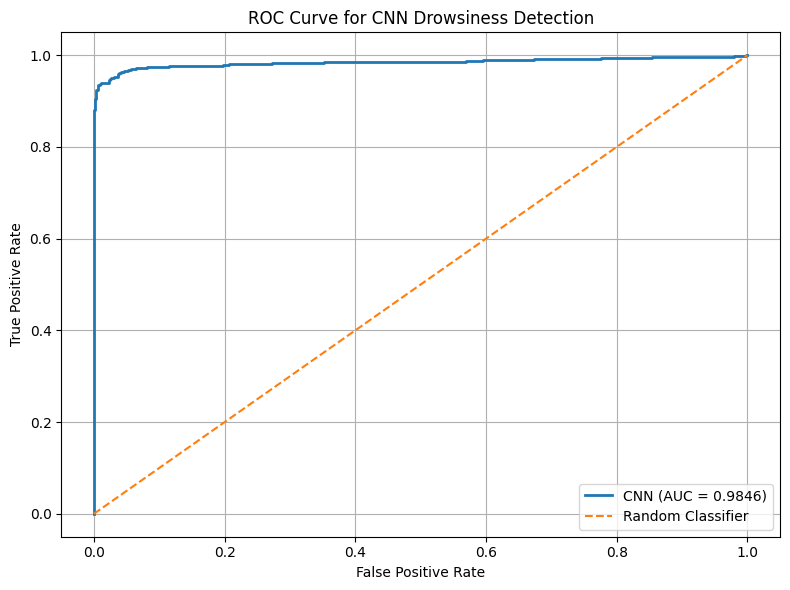

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate predicted probabilities
y_pred_prob = best_model.predict(X_test, verbose=0).flatten()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_prob)

print("========== ROC-AUC ANALYSIS ==========")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"ROC-AUC Score: {auc_score * 100:.2f}%")
print("======================================")

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CNN (AUC = {auc_score:.4f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CNN Drowsiness Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 21. FINAL MODEL EVALUATION SUMMARY

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print("=" * 55)
print("       FINAL CNN MODEL EVALUATION SUMMARY")
print("=" * 55)

print(f"Test Accuracy       : {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"Test Loss           : {test_loss:.4f}")
print(f"Precision            : {final_precision:.4f} ({final_precision * 100:.2f}%)")
print(f"Recall               : {final_recall:.4f} ({final_recall * 100:.2f}%)")
print(f"F1-Score             : {final_f1:.4f} ({final_f1 * 100:.2f}%)")
print(f"ROC-AUC              : {auc_score:.4f} ({auc_score * 100:.2f}%)")

print("-" * 55)
print("Best Training Epoch  : 5")
print("Total Epochs Run     : 10")
print("Training Images      : 2127")
print("Validation Images    : 236")
print("Testing Images       : 1637")
print("Input Image Size     : 64 x 64 x 1")
print("Classes              : Closed_Eyes, Open_Eyes")

print("=" * 55)

       FINAL CNN MODEL EVALUATION SUMMARY
Test Accuracy       : 0.9493 (94.93%)
Test Loss           : 0.2519
Precision            : 0.9969 (99.69%)
Recall               : 0.9242 (92.42%)
F1-Score             : 0.9592 (95.92%)
ROC-AUC              : 0.9846 (98.46%)
-------------------------------------------------------
Best Training Epoch  : 5
Total Epochs Run     : 10
Training Images      : 2127
Validation Images    : 236
Testing Images       : 1637
Input Image Size     : 64 x 64 x 1
Classes              : Closed_Eyes, Open_Eyes
